# Evaluation of the best Roman Rung 0 model

In this notebook we evaluate the best local model for Einstein radius regression.

Main goals:

- Load the best checkpoint
- Rebuild the dataset and test split
- Compute global metrics
- Compute metrics by target bins
- Visualize predictions
- Estimate predictive uncertainty with MC Dropout

In [8]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [9]:
#use dracula style
import matplotx
plt.style.use(matplotx.styles.dracula)

In [20]:
# -------- paths --------
H5_PATH = "roman_data_challenge_rung_0_v_1_0.h5"

CKPT_PATH = CKPT_PATH = "roman_rung0_runs/run_20260323_144337/tanh_convnext__mode-balanced_bins__bs-32__drop-0.2__wd-0.0003__lr-0.001__loss-huber__tt-log__norm-none/best_model.pt" 
# o la ruta real a tu mejor checkpoint

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIXEL_SCALE = 0.11
N_BINS = 8

print("DEVICE:", DEVICE)
print("Checkpoint exists:", os.path.exists(CKPT_PATH))
print("H5 exists:", os.path.exists(H5_PATH))

DEVICE: cuda
Checkpoint exists: True
H5 exists: True


In [11]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

def relative_error_stats(y_true, y_pred, eps=1e-8):
    rel = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), eps)
    return {
        "mean_relative_error": float(rel.mean()),
        "median_relative_error": float(np.median(rel)),
        "all_relative_errors": rel,
    }

def make_target_bins(y, n_bins=8):
    edges = np.quantile(y, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    bins = np.digitize(y, edges[1:-1], right=True)
    return bins, edges

def apply_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.log(y)
    else:
        raise ValueError(mode)

def invert_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.exp(y)
    else:
        raise ValueError(mode)

def safe_float_attr(attrs, key):
    return float(attrs[key][0])

In [12]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")

print("Checkpoint keys:", ckpt.keys())

exp_cfg = ckpt["exp_cfg"] if "exp_cfg" in ckpt else None
channel_mean = ckpt.get("channel_mean", None)
channel_std = ckpt.get("channel_std", None)
bin_edges_ckpt = ckpt.get("bin_edges", None)
target_transform = ckpt.get("target_transform", "none")
normalization_mode = ckpt.get("normalization_mode", "none")

print("exp_cfg:", exp_cfg)
print("target_transform:", target_transform)
print("normalization_mode:", normalization_mode)

Checkpoint keys: dict_keys(['model_state_dict', 'config', 'channel_mean', 'channel_std', 'bin_edges', 'bin_weights'])
exp_cfg: None
target_transform: none
normalization_mode: none


In [13]:
class TanhDepthwiseBlock(nn.Module):
    def __init__(self, c, dropout=0.0):
        super().__init__()
        self.dw = nn.Conv2d(c, c, 7, padding=3, groups=c, bias=False)
        self.bn1 = nn.BatchNorm2d(c)
        self.pw1 = nn.Conv2d(c, 4 * c, 1)
        self.pw2 = nn.Conv2d(4 * c, c, 1)
        self.act = nn.Tanh()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = self.dw(x)
        h = self.bn1(h)
        h = self.act(h)
        h = self.pw1(h)
        h = self.act(h)
        h = self.dropout(h)
        h = self.pw2(h)
        return self.act(x + h)

class TanhConvNeXtMini(nn.Module):
    def __init__(self, in_ch=3, width=32, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, width, 4, stride=2, padding=1),
            nn.BatchNorm2d(width),
            nn.Tanh(),
        )

        self.stage1 = nn.Sequential(
            TanhDepthwiseBlock(width, dropout=0.0),
            TanhDepthwiseBlock(width, dropout=0.0),
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(width, 2 * width, 2, stride=2),
            nn.BatchNorm2d(2 * width),
            nn.Tanh(),
        )
        self.stage2 = nn.Sequential(
            TanhDepthwiseBlock(2 * width, dropout=0.0),
            TanhDepthwiseBlock(2 * width, dropout=0.0),
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(2 * width, 4 * width, 2, stride=2),
            nn.BatchNorm2d(4 * width),
            nn.Tanh(),
        )
        self.stage3 = nn.Sequential(
            TanhDepthwiseBlock(4 * width, dropout=0.0),
            TanhDepthwiseBlock(4 * width, dropout=0.0),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(4 * width, 128),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down2(x)
        x = self.stage2(x)
        x = self.down3(x)
        x = self.stage3(x)
        return self.head(x)

In [18]:
#la buena
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1)
        self.conv2 = nn.Conv2d(c, c, 3, padding=1)

    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = self.conv2(h)
        return F.relu(x + h)

class ResNetMini(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU()
        )
        self.block1 = ResidualBlock(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.block2 = ResidualBlock(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.block3 = ResidualBlock(128)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.block2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.block3(x)

        return self.head(x)

In [19]:
print(ckpt["config"])

{'model_name': 'resnetmini', 'lr': 0.001, 'weight_decay': 5e-05, 'dropout': 0.2}


In [17]:
# ==========================================
# Construir modelo manualmente (robusto)
# ==========================================

dropout = 0.2   # ← el del best run

model = TanhConvNeXtMini(dropout=dropout).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Model loaded successfully")

RuntimeError: Error(s) in loading state_dict for TanhConvNeXtMini:
	Missing key(s) in state_dict: "stem.1.weight", "stem.1.bias", "stem.1.running_mean", "stem.1.running_var", "stage1.0.dw.weight", "stage1.0.bn1.weight", "stage1.0.bn1.bias", "stage1.0.bn1.running_mean", "stage1.0.bn1.running_var", "stage1.0.pw1.weight", "stage1.0.pw1.bias", "stage1.0.pw2.weight", "stage1.0.pw2.bias", "stage1.1.dw.weight", "stage1.1.bn1.weight", "stage1.1.bn1.bias", "stage1.1.bn1.running_mean", "stage1.1.bn1.running_var", "stage1.1.pw1.weight", "stage1.1.pw1.bias", "stage1.1.pw2.weight", "stage1.1.pw2.bias", "down2.0.weight", "down2.0.bias", "down2.1.weight", "down2.1.bias", "down2.1.running_mean", "down2.1.running_var", "stage2.0.dw.weight", "stage2.0.bn1.weight", "stage2.0.bn1.bias", "stage2.0.bn1.running_mean", "stage2.0.bn1.running_var", "stage2.0.pw1.weight", "stage2.0.pw1.bias", "stage2.0.pw2.weight", "stage2.0.pw2.bias", "stage2.1.dw.weight", "stage2.1.bn1.weight", "stage2.1.bn1.bias", "stage2.1.b

---

In [38]:
import torch
import os

CKPT_PATH = "roman_rung0_runs/run_20260323_144337/tanh_convnext__mode-balanced_bins__bs-32__drop-0.2__wd-0.0003__lr-0.001__loss-huber__tt-log__norm-none/best_model.pt"

print("exists:", os.path.exists(CKPT_PATH))

ckpt = torch.load(CKPT_PATH, map_location="cpu")
print(ckpt.keys())

if "exp_cfg" in ckpt:
    print("exp_cfg =", ckpt["exp_cfg"])
if "config" in ckpt:
    print("config =", ckpt["config"])

target_transform = ckpt.get("target_transform", "none")
normalization_mode = ckpt.get("normalization_mode", "none")
channel_mean = ckpt.get("channel_mean", None)
channel_std = ckpt.get("channel_std", None)
bin_edges_ckpt = ckpt.get("bin_edges", None)

print("target_transform:", target_transform)
print("normalization_mode:", normalization_mode)

exists: True
dict_keys(['model_state_dict', 'exp_cfg', 'channel_mean', 'channel_std', 'bin_edges', 'pixel_scale', 'center_crop', 'resize_to', 'target_transform', 'normalization_mode', 'best_epoch', 'best_val_loss'])
exp_cfg = {'arch': 'tanh_convnext', 'train_mode': 'balanced_bins', 'batch_size': 32, 'dropout': 0.2, 'weight_decay': 0.0003, 'max_lr': 0.001, 'loss_name': 'huber', 'target_transform': 'log', 'normalization_mode': 'none'}
target_transform: log
normalization_mode: none


In [39]:
import torch.nn as nn
import torch.nn.functional as F

class TanhDepthwiseBlock(nn.Module):
    def __init__(self, c, dropout=0.0):
        super().__init__()
        self.dw = nn.Conv2d(c, c, 7, padding=3, groups=c, bias=False)
        self.bn1 = nn.BatchNorm2d(c)
        self.pw1 = nn.Conv2d(c, 4 * c, 1)
        self.pw2 = nn.Conv2d(4 * c, c, 1)
        self.act = nn.Tanh()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = self.dw(x)
        h = self.bn1(h)
        h = self.act(h)
        h = self.pw1(h)
        h = self.act(h)
        h = self.dropout(h)
        h = self.pw2(h)
        return self.act(x + h)

class TanhConvNeXtMini(nn.Module):
    def __init__(self, in_ch=3, width=32, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, width, 4, stride=2, padding=1),
            nn.BatchNorm2d(width),
            nn.Tanh(),
        )

        self.stage1 = nn.Sequential(
            TanhDepthwiseBlock(width, dropout=0.0),
            TanhDepthwiseBlock(width, dropout=0.0),
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(width, 2 * width, 2, stride=2),
            nn.BatchNorm2d(2 * width),
            nn.Tanh(),
        )
        self.stage2 = nn.Sequential(
            TanhDepthwiseBlock(2 * width, dropout=0.0),
            TanhDepthwiseBlock(2 * width, dropout=0.0),
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(2 * width, 4 * width, 2, stride=2),
            nn.BatchNorm2d(4 * width),
            nn.Tanh(),
        )
        self.stage3 = nn.Sequential(
            TanhDepthwiseBlock(4 * width, dropout=0.0),
            TanhDepthwiseBlock(4 * width, dropout=0.0),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(4 * width, 128),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down2(x)
        x = self.stage2(x)
        x = self.down3(x)
        x = self.stage3(x)
        return self.head(x)

In [40]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

dropout = 0.2   # del mejor experimento
model = TanhConvNeXtMini(dropout=dropout).to(DEVICE)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Model loaded successfully on", DEVICE)

Model loaded successfully on cuda


In [41]:
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

H5_PATH = "roman_data_challenge_rung_0_v_1_0.h5"
SEED = 42
N_BINS = 8
PIXEL_SCALE = 0.11

def safe_float_attr(attrs, key):
    return float(attrs[key][0])

def load_system(group):
    uid = group.attrs["uid"][0]
    theta_e = safe_float_attr(group.attrs, "theta_e")

    r = group[f"exposure_{uid}_F158"][:].astype(np.float32)
    g = group[f"exposure_{uid}_F129"][:].astype(np.float32)
    b = group[f"exposure_{uid}_F106"][:].astype(np.float32)

    x = np.stack([r, g, b], axis=-1)
    return x, theta_e

def make_target_bins(y, n_bins=8):
    edges = np.quantile(y, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    bins = np.digitize(y, edges[1:-1], right=True)
    return bins, edges

def apply_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.log(y)
    else:
        raise ValueError(mode)

def invert_target_transform(y, mode):
    if mode == "none":
        return y
    elif mode == "log":
        return np.exp(y)
    else:
        raise ValueError(mode)

f = h5py.File(H5_PATH, "r")
images_group = f["images"]
all_keys = list(images_group.keys())

X_list, y_list = [], []
for k in all_keys:
    x, y = load_system(images_group[k])
    X_list.append(x)
    y_list.append(y)

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list, dtype=np.float32)

y_bins, bin_edges = make_target_bins(y, n_bins=N_BINS)
idx_all = np.arange(len(X))

idx_train, idx_tmp, yb_train, yb_tmp = train_test_split(
    idx_all, y_bins, test_size=0.30, random_state=SEED, stratify=y_bins
)
idx_val, idx_test, yb_val, yb_test = train_test_split(
    idx_tmp, yb_tmp, test_size=0.50, random_state=SEED, stratify=yb_tmp
)

class RomanEvalDataset(Dataset):
    def __init__(self, X, y, indices, target_transform="none", normalization_mode="none",
                 channel_mean=None, channel_std=None):
        self.X = X
        self.y = y
        self.indices = indices
        self.target_transform = target_transform
        self.normalization_mode = normalization_mode
        self.channel_mean = channel_mean
        self.channel_std = channel_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx].copy()
        yt = self.y[idx].astype(np.float32)

        x = np.log1p(x)

        if self.normalization_mode == "global_standard":
            x = (x - self.channel_mean[0]) / self.channel_std[0]
        elif self.normalization_mode == "per_image_max":
            x = x / (np.max(np.abs(x)) + 1e-8)
        elif self.normalization_mode == "none":
            pass
        else:
            raise ValueError(self.normalization_mode)

        x = np.transpose(x, (2, 0, 1)).astype(np.float32)
        yt_t = apply_target_transform(np.array([yt], dtype=np.float32), self.target_transform)[0]

        return torch.tensor(x), torch.tensor([yt_t], dtype=torch.float32), idx

test_ds = RomanEvalDataset(
    X, y, idx_test,
    target_transform=target_transform,
    normalization_mode=normalization_mode,
    channel_mean=channel_mean,
    channel_std=channel_std,
)

test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Test size:", len(test_ds))
print("target_transform:", target_transform)
print("normalization_mode:", normalization_mode)

Test size: 1674
target_transform: log
normalization_mode: none


In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

def relative_error_stats(y_true, y_pred, eps=1e-8):
    rel = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), eps)
    return {
        "mean_relative_error": float(rel.mean()),
        "median_relative_error": float(np.median(rel)),
        "all_relative_errors": rel,
    }

model.eval()
preds_t, trues_t, idxs = [], [], []

with torch.no_grad():
    for xb, yb, idxb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy().reshape(-1)
        preds_t.append(pred)
        trues_t.append(yb.numpy().reshape(-1))
        idxs.append(idxb.numpy())

y_pred_t = np.concatenate(preds_t)
y_true_t = np.concatenate(trues_t)
idxs_test_order = np.concatenate(idxs)

y_pred = invert_target_transform(y_pred_t, target_transform)
y_true = invert_target_transform(y_true_t, target_transform)

metrics = regression_metrics(y_true, y_pred)
rel = relative_error_stats(y_true, y_pred)

print(metrics)
print({k: rel[k] for k in ["mean_relative_error", "median_relative_error"]})

{'rmse': 0.13419131934642792, 'mae': 0.07050884515047073, 'r2': 0.9302318096160889}
{'mean_relative_error': 0.0875665545463562, 'median_relative_error': 0.06560026109218597}


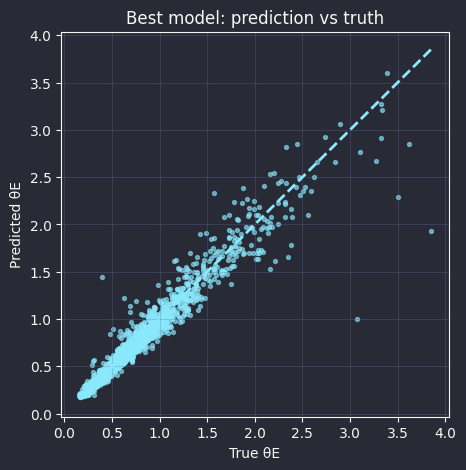

In [43]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=8, alpha=0.6)
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "--", linewidth=2)
plt.xlabel("True θE")
plt.ylabel("Predicted θE")
plt.title("Best model: prediction vs truth")
plt.grid(alpha=0.3)
plt.show()

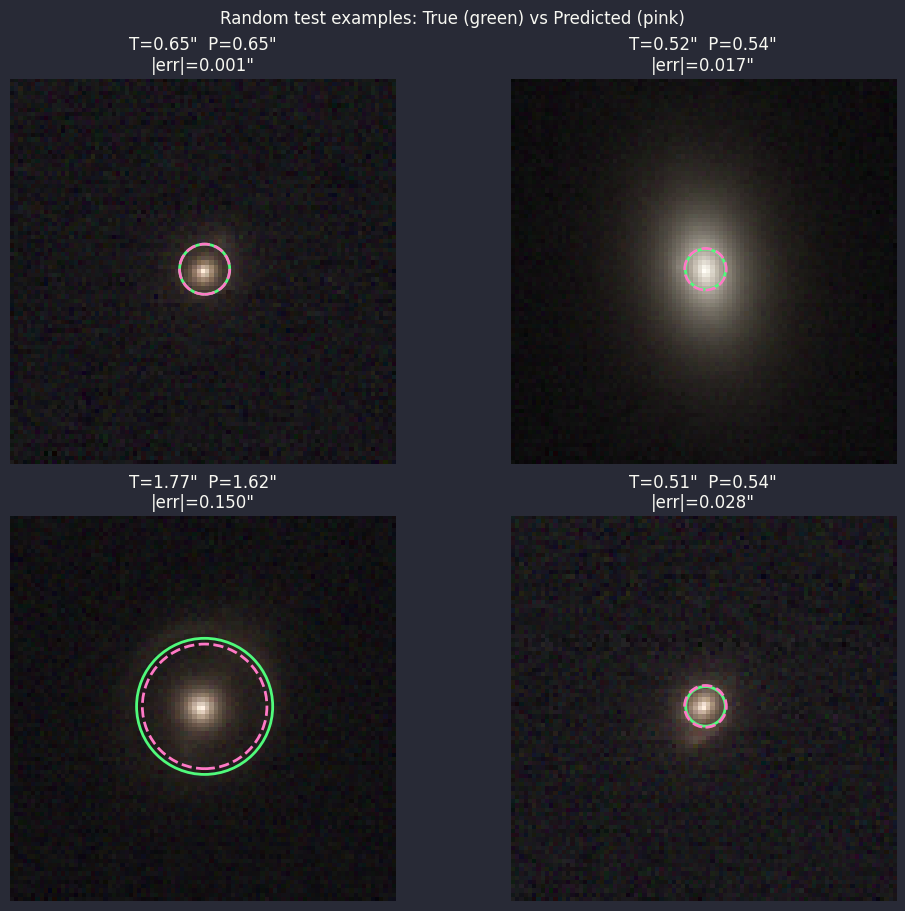

In [28]:
n_show = 4
sel = random.sample(range(len(idxs_test_order)), n_show)

fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
axes = axes.ravel()

for ax, j in zip(axes, sel):
    idx_global = idxs_test_order[j]
    img = X[idx_global].copy()

    disp = np.log1p(img)
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

    t = y_true[j]
    p = y_pred[j]

    ax.imshow(disp, origin="lower")

    h, w, _ = disp.shape
    center = (w / 2, h / 2)

    r_true = t / PIXEL_SCALE
    r_pred = p / PIXEL_SCALE

    ax.add_patch(plt.Circle(center, r_true, fill=False, linewidth=2, color="#50fa7b"))
    ax.add_patch(plt.Circle(center, r_pred, fill=False, linewidth=2, linestyle="--", color="#ff79c6"))

    ax.set_title(f'T={t:.2f}"  P={p:.2f}"\n|err|={abs(p-t):.3f}"')
    ax.axis("off")

plt.suptitle("Random test examples: True (green) vs Predicted (pink)")
plt.show()

In [29]:
print(metrics)
print({k: rel[k] for k in ["mean_relative_error", "median_relative_error"]})

{'rmse': 0.13419131934642792, 'mae': 0.07050884515047073, 'r2': 0.9302318096160889}
{'mean_relative_error': 0.0875665545463562, 'median_relative_error': 0.06560026109218597}


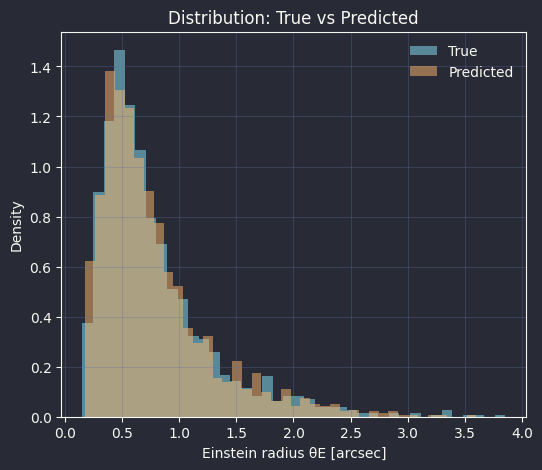

In [30]:
plt.figure(figsize=(6,5))

plt.hist(y_true, bins=40, alpha=0.5, label="True", density=True)
plt.hist(y_pred, bins=40, alpha=0.5, label="Predicted", density=True)

plt.xlabel("Einstein radius θE [arcsec]")
plt.ylabel("Density")
plt.title("Distribution: True vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

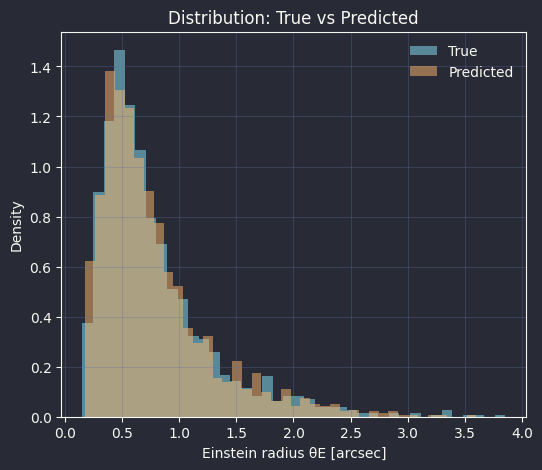

In [31]:
plt.figure(figsize=(6,5))

plt.hist(y_true, bins=40, alpha=0.5, label="True", density=True)
plt.hist(y_pred, bins=40, alpha=0.5, label="Predicted", density=True)

plt.xlabel("Einstein radius θE [arcsec]")
plt.ylabel("Density")
plt.title("Distribution: True vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

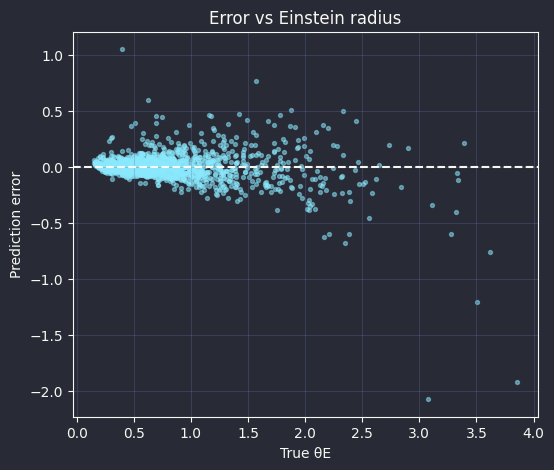

In [32]:
err = y_pred - y_true

plt.figure(figsize=(6,5))
plt.scatter(y_true, err, s=8, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("True θE")
plt.ylabel("Prediction error")
plt.title("Error vs Einstein radius")
plt.grid(alpha=0.3)
plt.show()

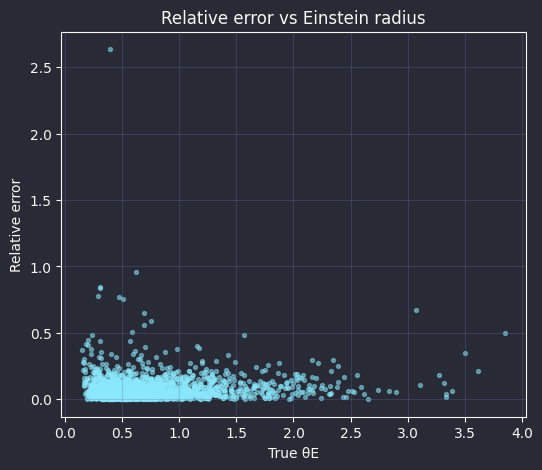

In [33]:
rel_err = np.abs(err) / y_true

plt.figure(figsize=(6,5))
plt.scatter(y_true, rel_err, s=8, alpha=0.5)

plt.xlabel("True θE")
plt.ylabel("Relative error")
plt.title("Relative error vs Einstein radius")
plt.grid(alpha=0.3)
plt.show()

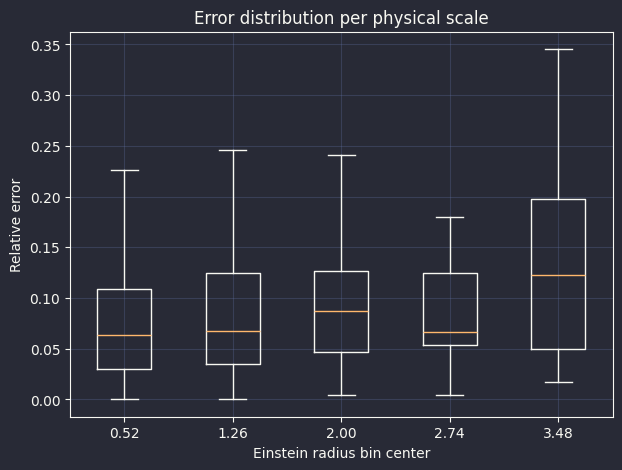

In [34]:
bins = np.linspace(y_true.min(), y_true.max(), 6)
digitized = np.digitize(y_true, bins)

box_data = [rel_err[digitized == i] for i in range(1, len(bins))]

plt.figure(figsize=(7,5))
plt.boxplot(box_data, showfliers=False)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(range(1, len(bin_centers)+1),
           [f"{c:.2f}" for c in bin_centers])

plt.xlabel("Einstein radius bin center")
plt.ylabel("Relative error")
plt.title("Error distribution per physical scale")
plt.grid(alpha=0.3)
plt.show()

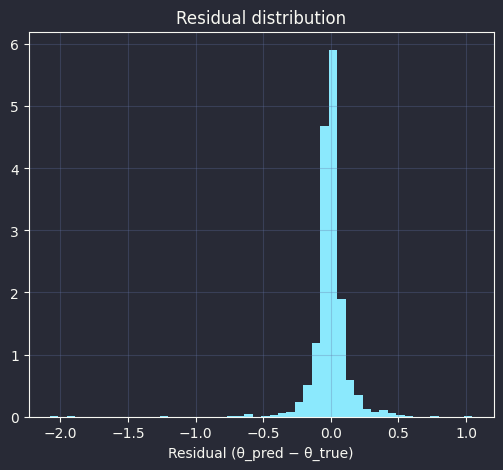

In [35]:
plt.figure(figsize=(6,5))
plt.hist(err, bins=50, density=True)

plt.xlabel("Residual (θ_pred − θ_true)")
plt.title("Residual distribution")
plt.grid(alpha=0.3)
plt.show()

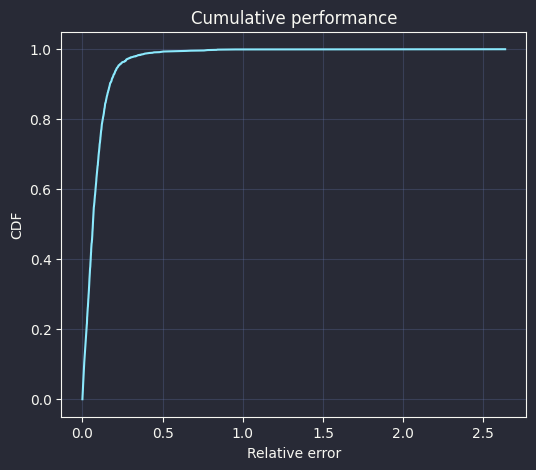

In [37]:
sorted_err = np.sort(rel_err)
cdf = np.arange(len(sorted_err)) / len(sorted_err)

plt.figure(figsize=(6,5))
plt.plot(sorted_err, cdf)

plt.xlabel("Relative error")
plt.ylabel("CDF")
plt.title("Cumulative performance")
plt.grid(alpha=0.3)
plt.show()